In [29]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [1]:
! pip install --upgrade scikit-learn scikeras

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.2
    Uninstalling scikit-learn-1.5.2:
      Successfully uninstalled scikit-learn-1.5.2


**1.	Exploratory Data Analysis (EDA)**

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('monthly_milk_production.csv',parse_dates=['Date'],index_col='Date')

In [4]:
df.shape

(168, 1)

In [5]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [7]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


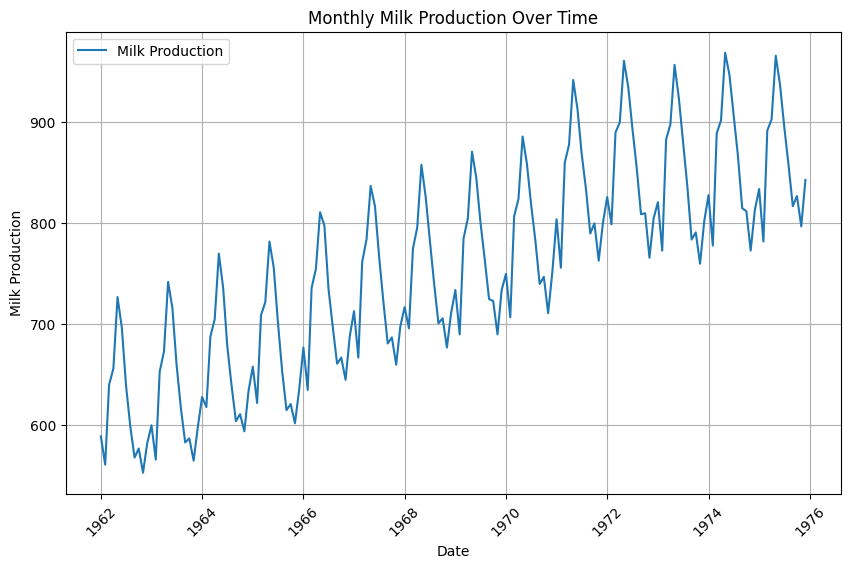

In [8]:
plt.figure(figsize=(10,6))
plt.plot(df['Production'], label='Milk Production')
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [9]:
result = seasonal_decompose(df['Production'],model='additive',period=12)

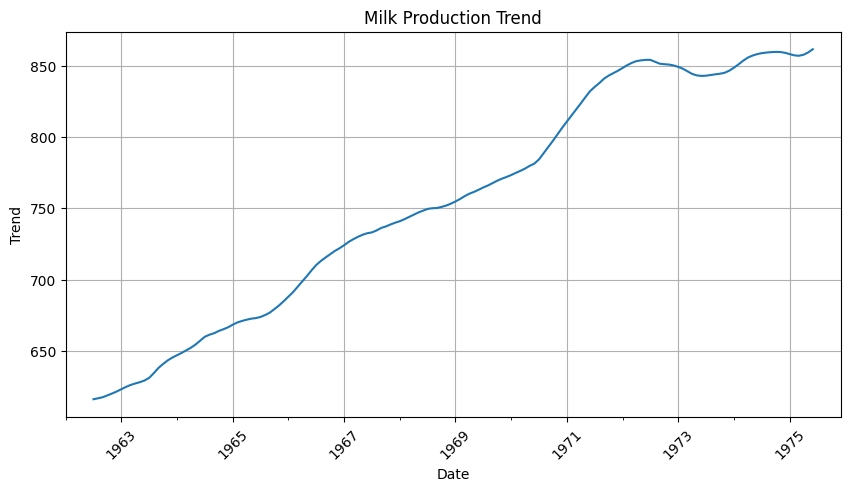

In [10]:
#Trend Component
result.trend.plot(figsize=(10,5))
plt.title('Milk Production Trend')
plt.xlabel('Date')
plt.ylabel('Trend')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

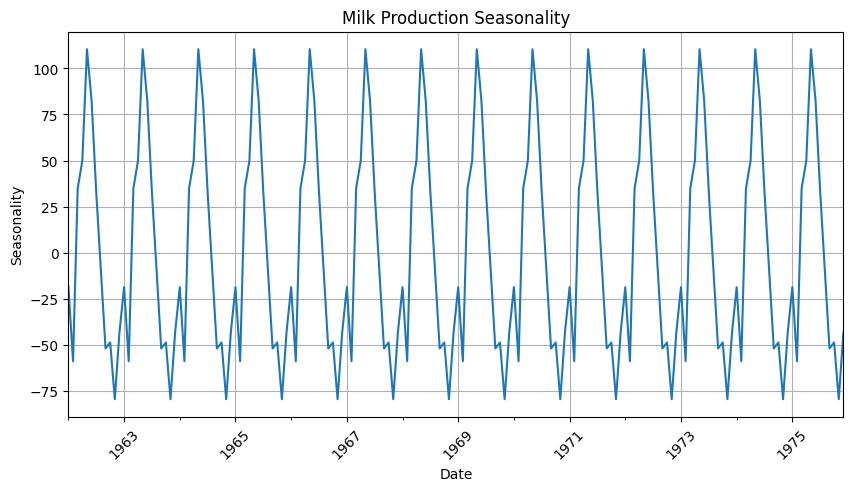

In [11]:
#Seasonal Component
result.seasonal.plot(figsize=(10,5))
plt.title('Milk Production Seasonality')
plt.xlabel('Date')
plt.ylabel('Seasonality')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

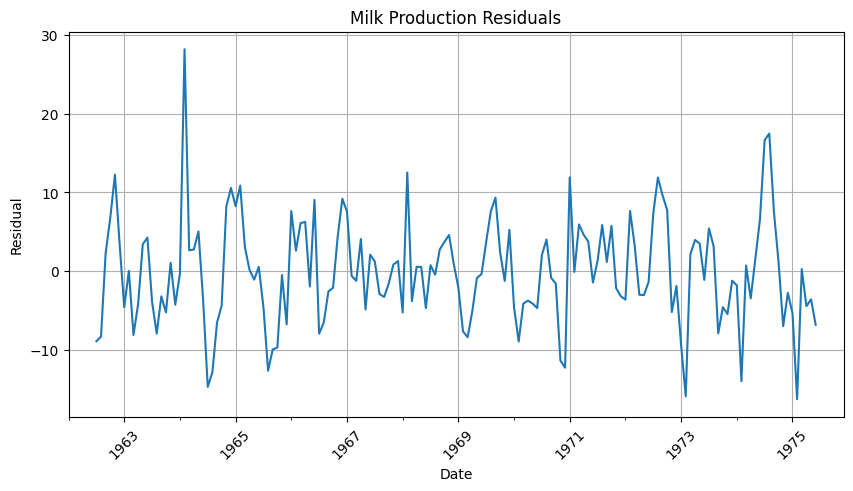

In [12]:
# Residual Component
result.resid.plot(figsize=(10,5))
plt.title('Milk Production Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [13]:
# checking missing values
df.isnull().sum()

,0
Production,0


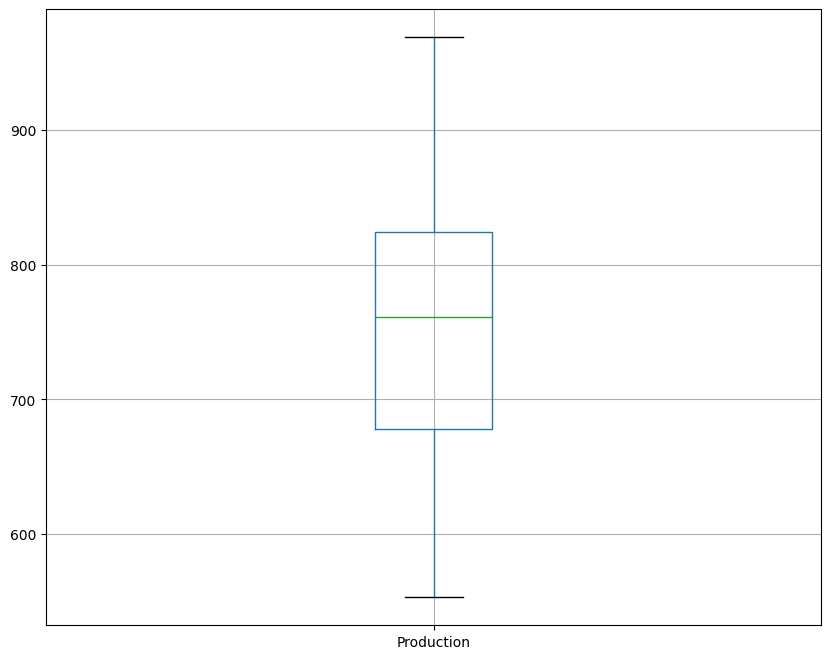

In [14]:
#checking outliers by using boxplot
plt.figure(figsize=(10,8))
df.boxplot()
plt.show()

In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Production']])

scaled_df = pd.DataFrame(scaled_data,columns=['Production_Scaled'],index=df.index)
scaled_df.head()

,Production_Scaled
Date,
1962-01-01,-1.626188
1962-02-01,-1.900967
1962-03-01,-1.125696
1962-04-01,-0.968679
1962-05-01,-0.271917


**2.	Data Preparation for Deep Learning**

In [16]:
data = scaled_df['Production_Scaled'].values
data

array([-1.62618756, -1.90096705, -1.12569634, -0.96867949, -0.27191721,
       -0.5663238 , -1.12569634, -1.52805203, -1.83227218, -1.7439502 ,
       -1.97947548, -1.69488243, -1.51823847, -1.85189929, -0.99812015,
       -0.80184908, -0.12471391, -0.37986629, -0.92942528, -1.35140807,
       -1.68506888, -1.64581467, -1.86171284, -1.53786558, -1.24345898,
       -1.34159452, -0.65464578, -0.48781538,  0.15006559, -0.18359523,
       -0.75278132, -1.1355099 , -1.47898426, -1.41028939, -1.57711979,
       -1.18457766, -0.94905238, -1.3023403 , -0.44856117, -0.32098497,
        0.26782823,  0.01267584, -0.51725604, -0.99812015, -1.37103518,
       -1.31215386, -1.49861137, -1.17476411, -0.76259487, -1.17476411,
       -0.18359523,  0.00286229,  0.55242127,  0.42484508, -0.19340878,
       -0.5663238 , -0.91961172, -0.8607304 , -1.07662858, -0.65464578,
       -0.40930695, -0.8607304 ,  0.07155716,  0.28745533,  0.80757366,
        0.61130259,  0.12062493, -0.32098497, -0.72334066, -0.66

In [17]:
# Function to create sequences
def create_sequences(data, window_size):

    x = []
    y = []
    for i in range(len(data)-window_size):
        x.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(x), np.array(y)

window_size = 12

x, y = create_sequences(scaled_df['Production_Scaled'].values,window_size)
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (156, 12)
y shape: (156,)


For time-series forecasting (RNN/LSTM/GRU), you can use train_test_split, but it is usually not preferred because the default behavior shuffles data, which breaks the chronological sequence.so,we use manual splitting.

In [18]:
# Split data
train_size = int(len(x)*0.70)
val_size = int(len(x)*0.15)

x_train = x[:train_size]
y_train = y[:train_size]

x_val = x[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

x_test = x[train_size+val_size:]
y_test = y[train_size+val_size:]

print("Training size:", x_train.shape)
print("Validation size:", x_val.shape)
print("Testing size:", x_test.shape)

Training size: (109, 12)
Validation size: (23, 12)
Testing size: (24, 12)


In [19]:
# Reshape inputs

x_train = x_train.reshape(x_train.shape[0],x_train.shape[1],1)

x_val = x_val.reshape(x_val.shape[0],x_val.shape[1],1)

x_test = x_test.reshape(x_test.shape[0],x_test.shape[1],1)

print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

x_train shape: (109, 12, 1)
x_val shape: (23, 12, 1)
x_test shape: (24, 12, 1)


**3.	Model Building**

In [20]:
import tensorflow as tf
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.callbacks import EarlyStopping

**RNN MODEL**

In [21]:
def create_rnn(units=50):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.SimpleRNN(units=units,input_shape=(x_train.shape[1],1)))
    model.add(tf.keras.layers.Dense(1))
    model.compile(optimizer='adam',loss='mse')
    return model

**Hyperparameters Tuning**

In [22]:
rnn_model = KerasRegressor(model=create_rnn,verbose=0)

In [23]:
params = {
    'model__units':[32,50,70],
    'batch_size':[16,32],
    'epochs':[30,50]
    }

In [24]:
grid_rnn = GridSearchCV(estimator=rnn_model,param_grid=params,cv=2)

In [25]:
grid_rnn.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasRegresso...se epochs=1 )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'batch_size': [16, 32], 'epochs': [30, 50], 'model__units': [32, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [26]:
print(grid_rnn.best_params_)

{'batch_size': 32, 'epochs': 30, 'model__units': 50}


**Final RNN Model**

In [27]:
rnn = tf.keras.models.Sequential()
rnn.add(tf.keras.layers.SimpleRNN(units=grid_rnn.best_params_['model__units'],input_shape=(x_train.shape[1],1)))
rnn.add(tf.keras.layers.Dense(1))
rnn.compile(optimizer='adam',loss='mse')
early_stop = EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)
rnn_history = rnn.fit(x_train,y_train,epochs=grid_rnn.best_params_['epochs'],batch_size=grid_rnn.best_params_['batch_size'],
                      validation_data=(x_val,y_val),callbacks=[early_stop])

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - loss: 0.6163 - val_loss: 0.3303
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.2603 - val_loss: 0.1091
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.2048 - val_loss: 0.1259
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1489 - val_loss: 0.1550
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1086 - val_loss: 0.1611
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0869 - val_loss: 0.1435
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0750 - val_loss: 0.1163
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0676 - val_loss: 0.1058
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0552 - val_loss: 0.1271
Epoch 10/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0494 - val_loss: 0.1325
Epoch 11/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0459 - val_loss: 0.1220
Epoch 12/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0415 - val_loss: 0.1013
E

**LSTM MODEL**

In [28]:
def create_lstm(units=50):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.LSTM(units=units,input_shape=(x_train.shape[1],1)))
    model.add(tf.keras.layers.Dense(1))
    model.compile(optimizer='adam',loss='mse')
    return model

**Hyperparameters Tuning**

In [29]:
lstm_model = KerasRegressor(model=create_lstm,verbose=0)

In [30]:
grid_lstm = GridSearchCV(estimator=lstm_model,param_grid=params,cv=2)

In [31]:
grid_lstm.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasRegresso...se epochs=1 )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'batch_size': [16, 32], 'epochs': [30, 50], 'model__units': [32, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [32]:
print(grid_lstm.best_params_)

{'batch_size': 32, 'epochs': 50, 'model__units': 70}


**Final Lstm Model**

In [33]:
lstm = tf.keras.models.Sequential()
lstm.add(tf.keras.layers.LSTM(units=grid_lstm.best_params_['model__units'],input_shape=(x_train.shape[1],1)))
lstm.add(tf.keras.layers.Dense(1))
lstm.compile(optimizer='adam',loss='mse')
lstm_history = lstm.fit(x_train,y_train,epochs=grid_lstm.best_params_['epochs'],batch_size=grid_lstm.best_params_['batch_size'],
    validation_data=(x_val,y_val),
    callbacks=[early_stop])

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - loss: 0.8302 - val_loss: 1.3166
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.6000 - val_loss: 1.0411
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.4804 - val_loss: 0.8243
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.4704 - val_loss: 0.6911
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4611 - val_loss: 0.6229
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.4311 - val_loss: 0.5946
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.4057 - val_loss: 0.5554
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.3895 - val_loss: 0.4994
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3723 - val_loss: 0.4499
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.3532 - val_loss: 0.4195


**GRU Model**

In [34]:
def create_gru(units=50):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.GRU(units=units,input_shape=(x_train.shape[1],1)))
    model.add(tf.keras.layers.Dense(1))
    model.compile(optimizer='adam',loss='mse')
    return model

**Hyperparameters Tuning**

In [35]:
gru_model = KerasRegressor(model=create_gru,verbose=0)

In [36]:
grid_gru = GridSearchCV(estimator=gru_model,param_grid=params,cv=2)

In [37]:
grid_gru.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasRegresso...se epochs=1 )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'batch_size': [16, 32], 'epochs': [30, 50], 'model__units': [32, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is als

In [38]:
print(grid_gru.best_params_)

{'batch_size': 16, 'epochs': 50, 'model__units': 50}


**Final GRU model**

In [39]:
gru = tf.keras.models.Sequential()
gru.add(tf.keras.layers.GRU(units=grid_gru.best_params_['model__units'],input_shape=(x_train.shape[1],1)))
gru.add(tf.keras.layers.Dense(1))
gru.compile(optimizer='adam',loss='mse')
gru_history = gru.fit(x_train,y_train,epochs=grid_gru.best_params_['epochs'],batch_size=grid_gru.best_params_['batch_size'],
    validation_data=(x_val,y_val),
    callbacks=[early_stop])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.7890 - val_loss: 1.2406
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5869 - val_loss: 1.0331
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.4952 - val_loss: 0.8535
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4392 - val_loss: 0.7114
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.4120 - val_loss: 0.6114
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3811 - val_loss: 0.5533
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3580 - val_loss: 0.5150
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.3416 - val_loss: 0.4817
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.3248 - val_loss: 0.4558
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3080 - val_loss: 0.4365


**4.	Model Evaluation**

In [40]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [41]:
# Predictions
rnn_pred = rnn.predict(x_test)
# Convert back to original scale
rnn_pred_actual = scaler.inverse_transform(rnn_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


In [42]:
# RNN metrics
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual,rnn_pred_actual))
rnn_mae = mean_absolute_error(y_test_actual,rnn_pred_actual)
rnn_mape = np.mean(np.abs((y_test_actual-rnn_pred_actual)/y_test_actual))*100
print("RNN RMSE:",rnn_rmse)
print("RNN MAE:",rnn_mae)
print("RNN MAPE:",rnn_mape)

RNN RMSE: 24.545208376089015
RNN MAE: 19.110623677571613
RNN MAPE: 2.192955348377278


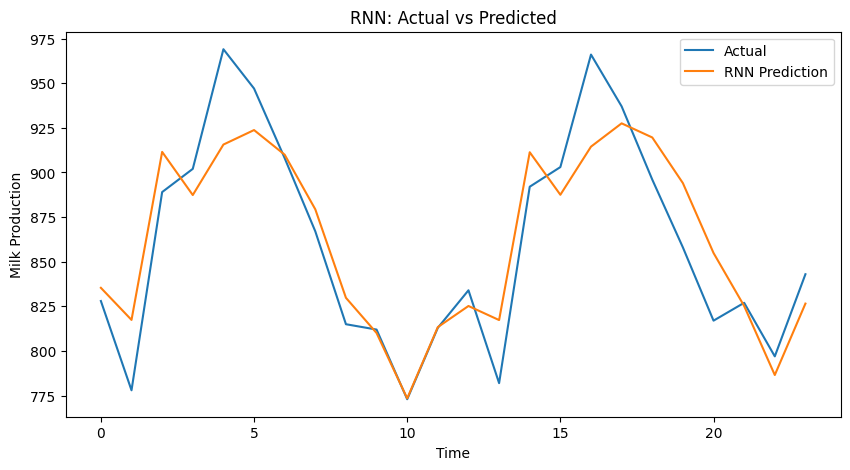

In [43]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual,label='Actual')
plt.plot(rnn_pred_actual,label='RNN Prediction')
plt.title("RNN: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [44]:
lstm_pred = lstm.predict(x_test)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


In [45]:
#LSTM metrics
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual,lstm_pred_actual))
lstm_mae = mean_absolute_error(y_test_actual,lstm_pred_actual)
lstm_mape = np.mean(np.abs((y_test_actual-lstm_pred_actual)/y_test_actual))*100
print("LSTM RMSE:",lstm_rmse)
print("LSTM MAE:",lstm_mae)
print("LSTM MAPE:",lstm_mape)

LSTM RMSE: 124.9945873404507
LSTM MAE: 108.74077860514323
LSTM MAPE: 12.216433862167458


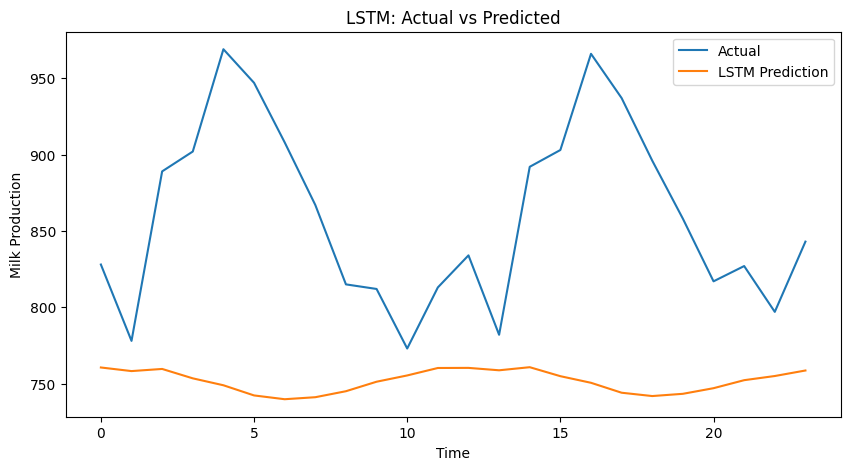

In [46]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual,label='Actual')
plt.plot(lstm_pred_actual,label='LSTM Prediction')
plt.title("LSTM: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [47]:
gru_pred = gru.predict(x_test)
gru_pred_actual = scaler.inverse_transform(gru_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step


In [48]:
# GRU metrics
gru_rmse = np.sqrt(mean_squared_error(y_test_actual,gru_pred_actual))
gru_mae = mean_absolute_error(y_test_actual,gru_pred_actual)
gru_mape = np.mean(np.abs((y_test_actual-gru_pred_actual)/y_test_actual) )*100
print("GRU RMSE:",gru_rmse)
print("GRU MAE:",gru_mae)
print("GRU MAPE:",gru_mape)

GRU RMSE: 120.87332497598285
GRU MAE: 104.77423604329427
GRU MAPE: 11.763032538467847


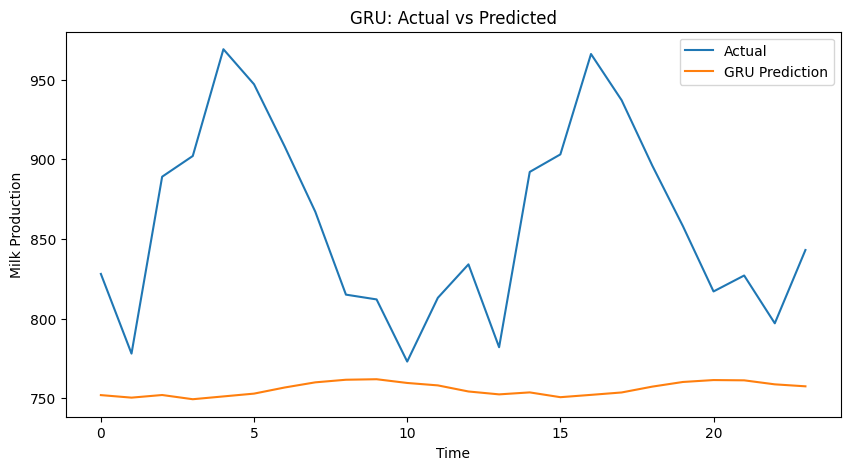

In [49]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual,label='Actual')
plt.plot(gru_pred_actual,label='GRU Prediction')
plt.title("GRU: Actual vs Predicted")
plt.xlabel("Time")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

In [50]:
comparison = pd.DataFrame({

    'Model':['RNN','LSTM','GRU'],

    'RMSE':[rnn_rmse,lstm_rmse,gru_rmse],
    'MAE':[rnn_mae,lstm_mae,gru_mae],
    'MAPE':[rnn_mape,lstm_mape,gru_mape]
})

print(comparison)

  Model        RMSE         MAE       MAPE
0   RNN   24.545208   19.110624   2.192955
1  LSTM  124.994587  108.740779  12.216434
2   GRU  120.873325  104.774236  11.763033


**5.	Prediction and Visualization**

In [51]:
# Take last sequence
last_sequence = x_test[-1]

future_predictions = []

# Predict next 12 months
for i in range(12):
    pred = lstm.predict(last_sequence.reshape(1, x_test.shape[1],1),verbose=0)
    future_predictions.append(pred[0][0])
    # Update sequence
    last_sequence = np.append(last_sequence[1:],pred)

In [52]:
# Convert Predictions to Original Scale
future_predictions = np.array(future_predictions).reshape(-1,1)
future_predictions = scaler.inverse_transform(future_predictions)

In [53]:
# Create Future Dates
future_dates = pd.date_range(start=df.index[-1],periods=13,freq='M')[1:]

In [54]:
# Forecast Table
forecast_df = pd.DataFrame({
    'Date':future_dates,
    'Forecasted_Milk_Production':
    future_predictions.flatten()
})

print(forecast_df)

         Date  Forecasted_Milk_Production
0  1976-01-31                  758.603210
1  1976-02-29                  762.367493
2  1976-03-31                  763.554443
3  1976-04-30                  763.807922
4  1976-05-31                  762.384216
5  1976-06-30                  760.554871
6  1976-07-31                  758.089783
7  1976-08-31                  755.900330
8  1976-09-30                  754.159607
9  1976-10-31                  752.862915
10 1976-11-30                  752.043030
11 1976-12-31                  751.118896


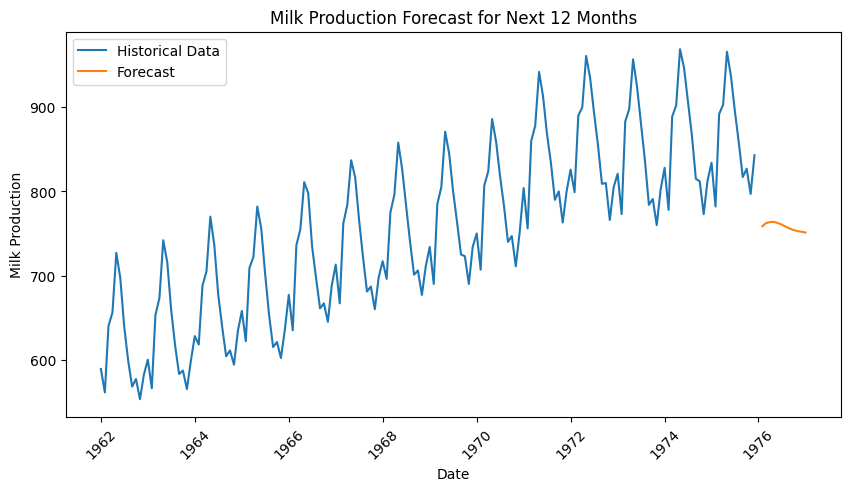

In [55]:
plt.figure(figsize=(10,5))
plt.plot(df.index,df.iloc[:,0],label='Historical Data')
plt.plot(future_dates,future_predictions,label='Forecast')
plt.title('Milk Production Forecast for Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.xticks(rotation=45)
plt.legend()
plt.show()

**6. Business Insights:**

The forecasting model helps estimate future milk production levels in advance.

The dairy business can use these predictions to plan storage, transportation, and supply chain activities more efficiently.

Expected high production periods can help increase workforce and inventory planning, while low production periods can help avoid excess storage and waste.

Forecasts support better resource allocation and improve decision-making for production and business growth.

Accurate predictions can help meet customer demand and reduce operational costs.